In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib
import dshape

# Geometry

### Line Segment

length = 3.605551242828369
midpoint = [1.5 1. ]
direction = [0.8320503 0.5547002]


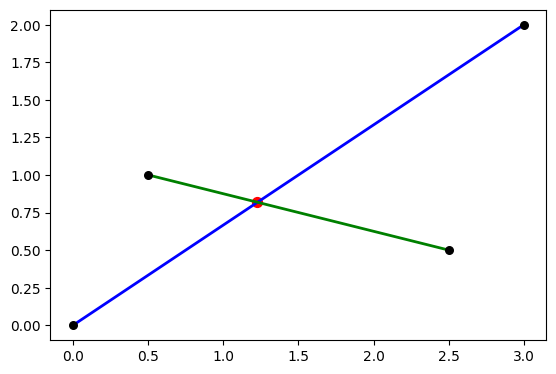

In [2]:
l1 = dshape.geometry.LineSegment([0., 0.], [3., 2.])
l2 = dshape.geometry.LineSegment([0.5, 1.0], [2.5, 0.5])
intersection = l1.intersection(l2)
print(f'length = {l1.length}')     # 5.0
print(f'midpoint = {l1.midpoint}')   # [1.5, 2.0]
print(f'direction = {l1.direction}')  # [0.6, 0.8] (unit vector)

fig, ax = plt.subplots()
l1.plot(ax=ax);
l2.plot(ax=ax, color='green');
if intersection is not None:
    intersection.plot(marker='o', color='red', ax=ax)

### Polygon with holes

p4.area = Array(8., dtype=float32)


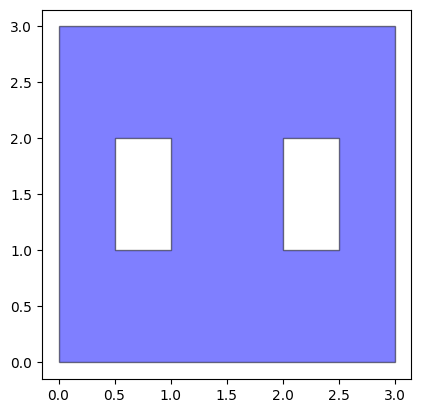

In [3]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Polygon.rectangle(0.5, 1, 0.5, 1)
p3 = dshape.geometry.Polygon.rectangle(2.0, 1, 0.5, 1)

p4 = p1 - p2 - p3
print(f"{p4.area = }")
p4.plot();

### MultiPolygon

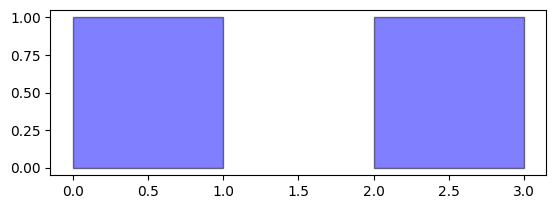

In [4]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 1)
p2 = dshape.geometry.Polygon.rectangle(1, -1, 1, 3)
p3 = p1 - p2

fig, ax = plt.subplots()
p3.plot(ax=ax);

### Island in a hole 

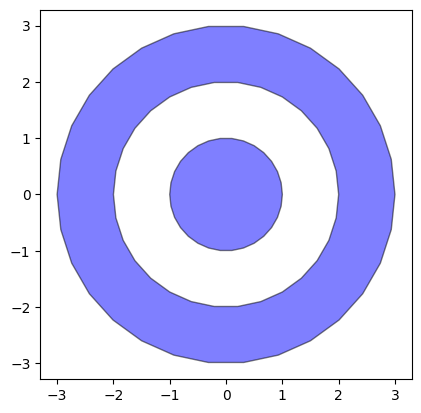

In [5]:
p1 = dshape.geometry.Polygon.circle((0, 0), 1.0)
p2 = dshape.geometry.Polygon.circle((0, 0), 2.0)
p3 = dshape.geometry.Polygon.circle((0, 0), 3.0)

p4 = dshape.geometry.Polygon.from_exteriors_interiors([p3, p1], [p2])
# p4 = (p3 - p2) + p1
p4.plot();

In [6]:
len(p4.exteriors)

2

In [7]:
len(p4.interiors)

1

### Convex Hull

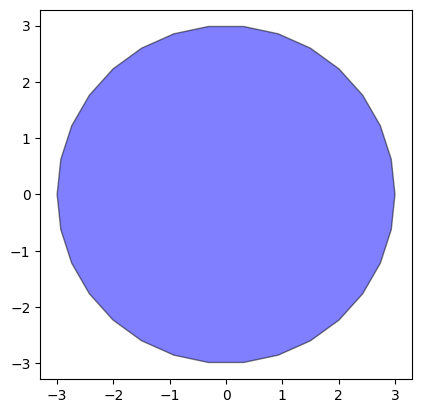

In [8]:
p4 = p3.convex_hull
p4.plot();

# Set operations

2


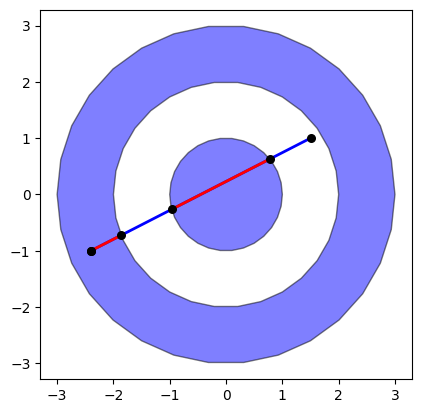

In [9]:
l1 = dshape.geometry.LineSegment([-2.4, -1.0], [1.5, 1.0])
p1 = dshape.geometry.Polygon.circle((0, 0), 1.0)
p2 = dshape.geometry.Polygon.circle((0, 0), 2.0)
p3 = dshape.geometry.Polygon.circle((0, 0), 3.0)
p4 = dshape.geometry.Polygon.from_exteriors_interiors([p1, p3], [p2])
intersection = l1.intersection(p4)
print(len(intersection))

fig, ax = plt.subplots()
p4.plot(ax)
l1.plot(ax)
for seg in intersection:
    seg.plot(ax, color='red')
plt.show()

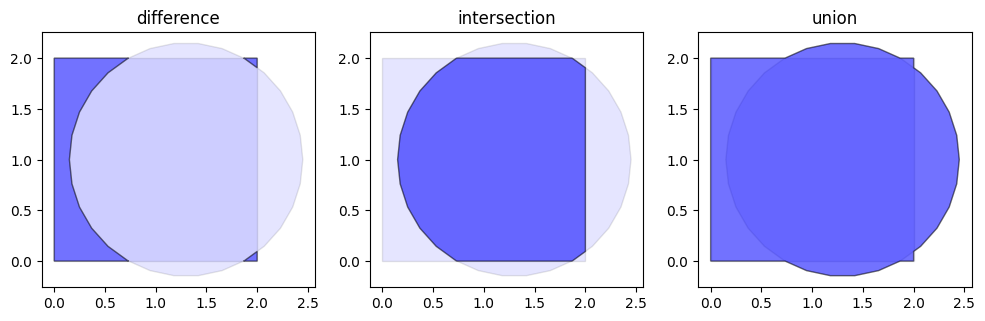

In [10]:
p1 = dshape.geometry.Polygon.rectangle(0.0, 0.0, 2.0, 2.0)
p2 = dshape.geometry.Polygon.circle((1.3, 1.0), 1.15)

diff_poly = p1 - p2
intersection_poly = p1 * p2
union_poly = p1 + p2

_, ax = plt.subplots(figsize=(12, 4), ncols=3)

for i in range(3):
    ax[i].set_aspect("equal")
    p1.plot(ax[i], alpha=0.1)
    p2.plot(ax[i], alpha=0.1)

diff_poly.plot(ax[0], color="blue")
ax[0].set_title("difference")
intersection_poly.plot(ax[1], color="blue")
ax[1].set_title("intersection")
union_poly.plot(ax[2], color="blue")
ax[2].set_title("union")

plt.show()

# Mutation

### Dilation

p1.count = 30
p2.count = Array(70, dtype=int32, weak_type=True)


<Axes: >

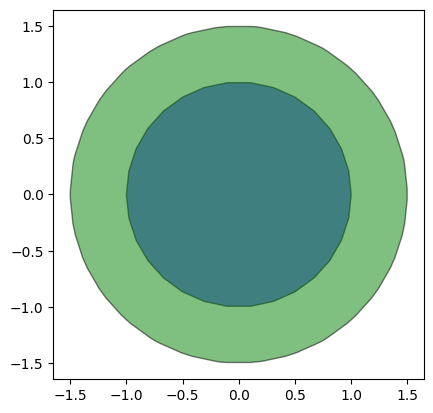

In [11]:
p1 = dshape.geometry.Polygon.circle((0, 0), 1.0)
print(f'{p1.count = }')
p2 = p1.buffer(0.5)
print(f'{p2.count = }')
fig, ax = plt.subplots()
p1.plot(ax=ax, color='blue')
p2.plot(ax=ax, color='green')

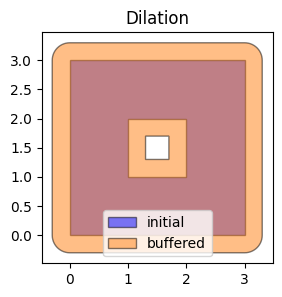

In [12]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Polygon.rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.3)

fig, ax = plt.subplots(figsize=(3, 3))
p3.plot(ax=ax, label='initial')
p4.plot(ax=ax, color='tab:orange', label='buffered')
ax.legend()
ax.set_title('Dilation');

### Rotation

In [13]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Polygon.rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.3)
p5 = p4.rotate(jnp.pi / 4, center=jnp.array([2.0, 1.5]))
dshape.plotting.plot_polygons([p1, p2, p3, p5])

### Scale

In [14]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Polygon.rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.3)
p5 = p4.scale(1.5, origin=(1.5, 1.5))
dshape.plotting.plot_polygons([p1, p2, p3, p5])

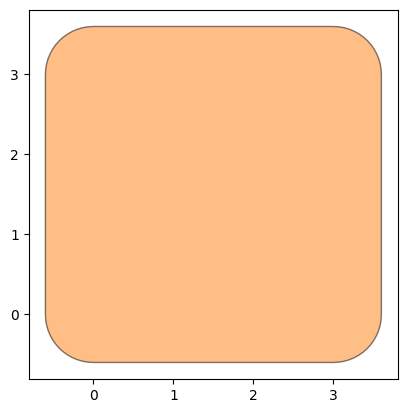

In [15]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Polygon.rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(0.6)

fig, ax = plt.subplots()
p4.plot(ax=ax, color='tab:orange');

### Erosion

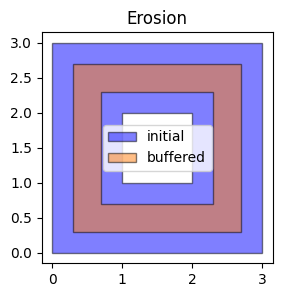

In [16]:
p1 = dshape.geometry.Polygon.rectangle(0, 0, 3, 3)
p2 = dshape.geometry.Polygon.rectangle(1, 1, 1, 1)
p3 = p1 - p2
p4 = p3.buffer(-0.3)

fig, ax = plt.subplots(figsize=(3, 3))
p3.plot(ax=ax, label="initial")
p4.plot(ax=ax, color="tab:orange", label="buffered")
ax.legend()
ax.set_title("Erosion");

### L shape

0.56
False


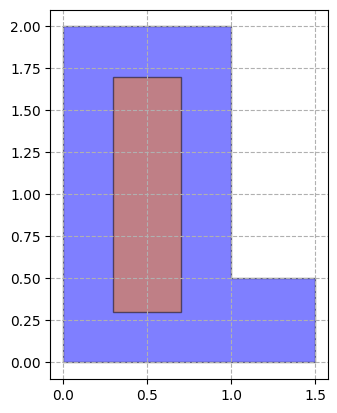

In [17]:
vertices = jnp.array(
    [[0.0, 0.0], [1.5, 0.0], [1.5, 0.5], [1.0, 0.5], [1.0, 2.0], [0.0, 2.0]],
    dtype=jnp.float32,
)
p1 = dshape.geometry.Polygon(vertices=vertices)
p2 = dshape.mutation.buffer(p1, -0.3)

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')
print(p2.area)
print(p2.self_intersect)
ax.grid(True, linestyle='--');

# Plotting using plotly

In [18]:
p1 = dshape.geometry.Polygon.circle((0, 0), 1.15)
p2 = p1.buffer(-1.0)
print(f'{p2.area = }')
dshape.plotting.plot_polygons([p1, p2])

p2.area = Array(0.06511123, dtype=float32)


# Staircase

p1.area = Array(0.5, dtype=float32)
p2.area = Array(1.3082606, dtype=float32)


<Axes: >

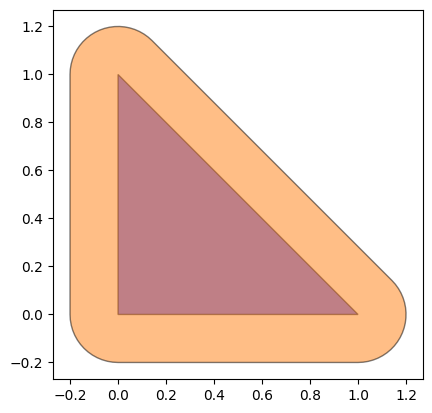

In [19]:
p1 = dshape.geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ]
    )
)
p2 = p1.buffer(0.2)
print(f"{p1.area = }")
print(f"{p2.area = }")

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax, color='tab:orange')

# Multiple staircases

p5.area = Array(1.0219493, dtype=float32)


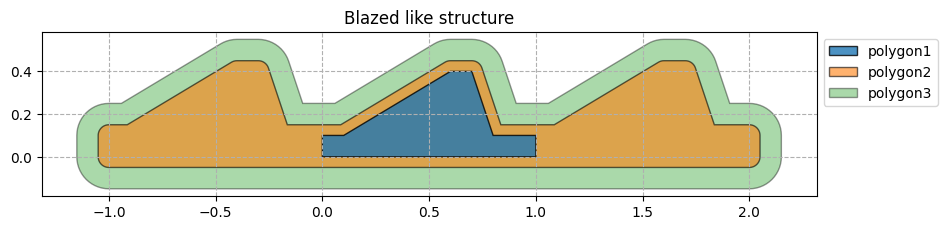

In [20]:
p1 = dshape.geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [1.0, 0.1],
            [0.8, 0.1],
            [0.7, 0.4],
            [0.6, 0.4],
            [0.1, 0.1],
            [0, 0.1],
        ]
    )
)
p2 = p1.buffer(0.05)
p3 = p2.translate((1.0, 0.0))
p4 = p2.translate((-1.0, 0.0))
p5 = p2 + p3 + p4

p2b = p1.buffer(0.15)
p3b = p2b.translate((1.0, 0.0))
p4b = p2b.translate((-1.0, 0.0))
p5b = p2b + p3b + p4b

print(f"{p5.area = }")

fig, ax = plt.subplots(figsize=(10, 4))
p5b.plot(ax=ax, label="polygon3", color="tab:green", alpha=0.4)
p5.plot(ax=ax, label="polygon2", color="tab:orange", alpha=0.6)
p1.plot(ax=ax, label="polygon1", color="tab:blue", alpha=0.8)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), reverse=True)
ax.grid(True, linestyle="dashed")
ax.set_title("Blazed like structure");

In [21]:
dshape.plotting.plot_polygons([p1, p5, p5b], title="Blazed like structure")

# Differentiability

In [24]:
def calculate_intersection_area(
    offset1: jax.Array, offset2: jax.Array, plot: bool = False
) -> jax.Array:
    p1a = dshape.geometry.Polygon.circle((0, 0), 1)
    p1b = p1a.translate(offset1)
    p1 = (p1a + p1b).convex_hull

    p2a = dshape.geometry.Polygon.circle((0, 0), 0.5)
    p2b = p2a.translate(offset1)
    p2 = (p2a + p2b).convex_hull

    p12 = p1 - p2

    p3a = dshape.geometry.Polygon.circle((4, 4), 1).buffer(-0.2)
    p3b = p3a.translate(offset2)
    p3 = (p3a + p3b).convex_hull

    p4 = p12 * p3

    if plot:
        fig, ax = plt.subplots()
        p12.plot(ax, color="red", label="p12")
        p3.plot(ax, color="green", label="p3")
        p4.plot(ax, color="blue", label="p4")
        ax.legend()
        plt.show()

    return p4.area


grad_area = jax.grad(calculate_intersection_area, argnums=(0, 1))

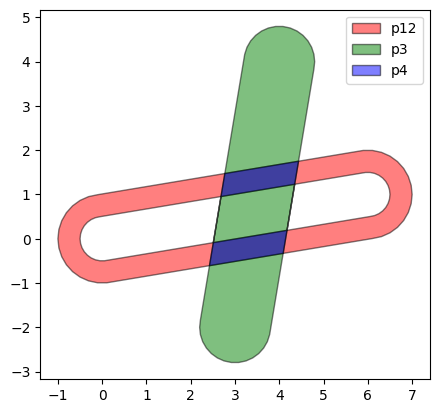

Array(1.6843629, dtype=float32)

In [25]:
calculate_intersection_area((6.0, 1.0), (-1.0, -6.0), plot=True)

In [27]:
grad_area((6.0, 1.0), (-1.0, -6.0))

((Array(-0.01285373, dtype=float32, weak_type=True),
  Array(0.07712239, dtype=float32, weak_type=True)),
 (Array(-0.10575348, dtype=float32, weak_type=True),
  Array(0.01762562, dtype=float32, weak_type=True)))